# **DAC NSGA-II Optimization workflow**

In [2]:
import xgboost as xgb
import pandas as pd
from xgboost import XGBRegressor
import numpy as np
from pymoo.core.problem import Problem
import matplotlib.pyplot as plt

In [3]:
#load efficiency model
DAC_eff_model = xgb.XGBRegressor()
DAC_eff_model.load_model("DAC_efficiency_XGBmodel.json")


In [4]:
#Load specific energy cost per co2 consumed model (SECC)
DAC_SECC_model = XGBRegressor()
DAC_SECC_model.load_model("DAC_SECC_XGBmodel.json")

In [5]:
wrangled_df = pd.read_csv("wrangled_DAC_simuation_results.csv")
wrangled_df

,caco3_flow_rate_kmol/hr,calciner_temp_DegC,pellet_moisture_frac,air_mol_flow_rate_kmol/hr,RH_air,DAC_column_height_m,pellet_diameter_mm,DAC_ambient_temp_DegC,e_voidage,capture_efficiency_%,SECC
0,97.514977,921.285152,0.493512,8833.277513,0.801022,4.919290,3.805631,21.742198,0.439079,6.523143,105.410825
1,31.906558,939.507047,0.333939,8082.465700,0.767765,2.624554,5.462603,34.839420,0.427176,1.830091,160.762374
2,66.419432,929.838273,0.426463,7335.719044,0.836021,1.900874,4.928280,24.921964,0.429412,2.375498,130.359369
3,99.038780,900.174052,0.347316,7315.145793,0.575318,9.355005,4.346817,38.664208,0.397470,6.788364,171.617326
4,98.462316,905.306138,0.112064,7753.304554,0.248262,2.872001,1.768148,41.269448,0.434394,3.421679,257.358216
...,...,...,...,...,...,...,...,...,...,...,...
1017,50.419064,931.582229,0.154068,7646.329962,0.871272,2.471474,2.465906,36.134729,0.415279,6.811835,80.651848
1018,20.367716,905.685989,0.261500,7404.025181,0.680243,8.748796,2.436164,15.250342,0.353304,10.254122,152.912984
1019,13.269341,943.607141,0.311672,8443.948358,0.492100,5.956748,2.016575,34.602614,0.440534,4.463911,228.219735
1020,24.203261,930.235680,0.242999,8127.516368,0.417274,5.403669,4.581640,40.993224,0.449766,1.717949,300.314345


In [6]:
#Feature matrix
X = wrangled_df.drop(columns=["SECC", "capture_efficiency_%"])
X

,caco3_flow_rate_kmol/hr,calciner_temp_DegC,pellet_moisture_frac,air_mol_flow_rate_kmol/hr,RH_air,DAC_column_height_m,pellet_diameter_mm,DAC_ambient_temp_DegC,e_voidage
0,97.514977,921.285152,0.493512,8833.277513,0.801022,4.919290,3.805631,21.742198,0.439079
1,31.906558,939.507047,0.333939,8082.465700,0.767765,2.624554,5.462603,34.839420,0.427176
2,66.419432,929.838273,0.426463,7335.719044,0.836021,1.900874,4.928280,24.921964,0.429412
3,99.038780,900.174052,0.347316,7315.145793,0.575318,9.355005,4.346817,38.664208,0.397470
4,98.462316,905.306138,0.112064,7753.304554,0.248262,2.872001,1.768148,41.269448,0.434394
...,...,...,...,...,...,...,...,...,...
1017,50.419064,931.582229,0.154068,7646.329962,0.871272,2.471474,2.465906,36.134729,0.415279
1018,20.367716,905.685989,0.261500,7404.025181,0.680243,8.748796,2.436164,15.250342,0.353304
1019,13.269341,943.607141,0.311672,8443.948358,0.492100,5.956748,2.016575,34.602614,0.440534
1020,24.203261,930.235680,0.242999,8127.516368,0.417274,5.403669,4.581640,40.993224,0.449766


In [7]:
#target vector
target1 = "capture_efficiency_%"
target2 = "SECC"
y1 = wrangled_df[target1]
y2 = wrangled_df[target2]

In [8]:
print("Target 1 is :", y1)
print("Target 2 is:", y2)

Target 1 is : 0        6.523143
1        1.830091
2        2.375498
3        6.788364
4        3.421679
          ...    
1017     6.811835
1018    10.254122
1019     4.463911
1020     1.717949
1021     3.853852
Name: capture_efficiency_%, Length: 1022, dtype: float64
Target 2 is: 0       105.410825
1       160.762374
2       130.359369
3       171.617326
4       257.358216
           ...    
1017     80.651848
1018    152.912984
1019    228.219735
1020    300.314345
1021    247.078473
Name: SECC, Length: 1022, dtype: float64


In [80]:
efficiency_predicted = DAC_SECC_model.predict(X)

In [83]:
arr  = efficiency_predicted

In [124]:
for num in arr:
    if num < 0:
        print(num)

In [11]:
secc_pred = DAC_SECC_model.predict(X[60:80])

In [12]:
print(secc_pred)

[ 88.57273  246.22885  133.97273  105.298744 428.56454  129.21393
 279.26492  172.44719  328.13107  388.14893  236.47665  132.2286
 180.84088  266.97443  422.2935   106.44473  138.90411   97.747795
 273.47955  415.2419  ]


# 1. Optimization Class definition

In [13]:
class DirectAirCaptureOptimizer(Problem):
    def __init__(self):
        
        #Define the variable ranges from using the LHS bounds
        lhs_variables =  {
        "caco3_flow_rate [kmol/hr]": [5, 100],                       # in kmol/hr
        "calciner_temp [Deg C]": [890, 950],                            #calciner temp without too much sintering (in degree c)
        "pellet_moisture_frac": [0.05, 0.5],                            # a decimal number
        "air_mol_flow_rate [kmol/hr]": [7000, 9000],                    # in kmol/hr
        "RH_air": [0.1, 0.9],                                           # relative humidity, less than 1
        "DAC_column_height [m]": [1.0, 10.0],                            # height in meters
        "pellet_diameter [mm]": [1.0, 6.0],                             # in mm
        "DAC_ambient_temp [Deg C]": [15, 45],                           # in degree celsius
        "e_voidage": [0.35, 0.45]                                         #Voidage in the DAC unit
        }
        self.lhs_variables = lhs_variables
        
        super().__init__(
            n_var=len(self.lhs_variables),
            n_obj=2,
            xl=[values[0] for values in self.lhs_variables.values()],
            xu=[values[1] for values in self.lhs_variables.values()],
        )
    def _evaluate(self, X, out, *args, **kwargs):
        DAC_efficiency = DAC_eff_model.predict(X)
        DAC_SECC = DAC_SECC_model.predict(X)

        #Objective minimization
        out["F"] = np.column_stack([
            -DAC_efficiency, DAC_SECC  
        ])

            
            
    

# 2. Run NSGA-II Algorithm 

In [14]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

algorithm = NSGA2(pop_size=1000)

result = minimize(
    DirectAirCaptureOptimizer(),
    algorithm,
    ('n_gen', 250),
    seed=1,
    verbose=True
)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |     1000 |      1 |             - |             -
     2 |     2000 |      2 |  1.0000000000 |         ideal
     3 |     3000 |      1 |  6.6222820282 |         ideal
     4 |     4000 |      3 |  0.6923936593 |         ideal
     5 |     5000 |      4 |  0.9518050330 |         ideal
     6 |     6000 |      2 |  0.5536345742 |         ideal
     7 |     7000 |      4 |  0.5216343557 |         ideal
     8 |     8000 |      6 |  0.1401728483 |         ideal
     9 |     9000 |      7 |  0.2609044216 |         ideal
    10 |    10000 |      9 |  0.1862965724 |         ideal
    11 |    11000 |      7 |  0.3317126643 |         ideal
    12 |    12000 |     10 |  0.0399984855 |             f
    13 |    13000 |     12 |  0.0101685990 |         ideal
    14 |    14000 |      8 |  0.1178949867 |         ideal
    15 |    15000 |     14 |  0.0819635487 |         ideal
    16 |    16000 |     16 |  0.0668830798 |         ide

# 3. Access Results

In [15]:
print(result.F)

[[-49.81574631 -13.83540535]
 [-49.81574631 -13.83540535]
 [-65.62187958  10.95054245]
 ...
 [-63.42315292  -3.09137392]
 [-60.57018661  -9.10466194]
 [-64.87397766  -2.83277559]]


In [16]:
print(result.X)

[[9.76405913e+01 9.47125303e+02 3.33040327e-01 ... 1.01951070e+00
  4.37418658e+01 3.55757719e-01]
 [9.76455308e+01 9.47125303e+02 3.33209699e-01 ... 1.01594902e+00
  4.37429284e+01 3.55754399e-01]
 [9.78637877e+01 9.19904840e+02 6.45313446e-02 ... 1.04919114e+00
  4.27147688e+01 3.53125260e-01]
 ...
 [9.76599994e+01 9.44685925e+02 2.66190910e-01 ... 1.01011920e+00
  4.37791251e+01 3.53143116e-01]
 [9.78523003e+01 9.44900236e+02 6.45341056e-02 ... 1.02185733e+00
  4.37343737e+01 3.81133020e-01]
 [9.76175345e+01 9.36586612e+02 6.53855232e-02 ... 1.01528793e+00
  4.37405958e+01 3.52893316e-01]]


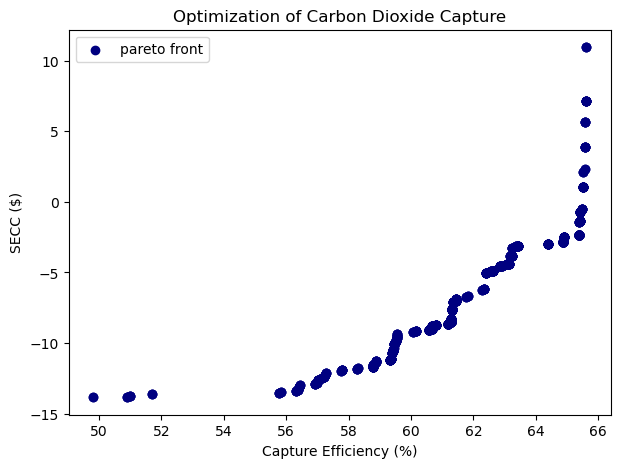

In [130]:
#PLot the optimization results
plt.figure(figsize=(7, 5))
DAC_efficiency = -result.F[:, 0]
SECC = result.F[:, 1]
plt.scatter(DAC_efficiency, SECC, color="navy", label="pareto front")
plt.title("Optimization of Carbon Dioxide Capture")
plt.xlabel("Capture Efficiency (%)")
plt.ylabel("SECC ($)")
plt.legend()

In [18]:
#Storing the results
input_parameters = result.X
objectives = result.F

In [109]:
       optimization_results =  {
        "caco3_flow_rate [kmol/hr]": input_parameters[:, 0],                       # in kmol/hr
        "calciner_temp [Deg C]": input_parameters[:, 1],                            #calciner temp without too much sintering (in degree c)
        "pellet_moisture_frac": input_parameters[:, 2],                            # a decimal number
        "air_mol_flow_rate [kmol/hr]": input_parameters[:, 3],                    # in kmol/hr
        "RH_air": input_parameters[:, 4],                                           # relative humidity, less than 1
        "DAC_column_height [m]": input_parameters[:, 5],                            # height in meters
        "pellet_diameter [mm]": input_parameters[:, 6],                             # in mm
        "DAC_ambient_temp [Deg C]": input_parameters[:, 7],                           # in degree celsius
        "e_voidage": input_parameters[:, 8],                                         #Voidage in the DAC unit
        "capture_efficiency_%": -objectives[:, 0],
        "SECC_$": objectives[:, 1]
       }

In [110]:
wrangled_df.columns

Index(['caco3_flow_rate_kmol/hr', 'calciner_temp_DegC', 'pellet_moisture_frac',
       'air_mol_flow_rate_kmol/hr', 'RH_air', 'DAC_column_height_m',
       'pellet_diameter_mm', 'DAC_ambient_temp_DegC', 'e_voidage',
       'capture_efficiency_%', 'SECC'],
      dtype='object')

In [111]:
df_optimal = pd.DataFrame(optimization_results)

In [128]:
df_optimal.to_csv("pareto_points.csv", index=False, encoding="utf-8")

In [112]:
df_optimal.head()

,caco3_flow_rate [kmol/hr],calciner_temp [Deg C],pellet_moisture_frac,air_mol_flow_rate [kmol/hr],RH_air,DAC_column_height [m],pellet_diameter [mm],DAC_ambient_temp [Deg C],e_voidage,capture_efficiency_%,SECC_$
0,97.640591,947.125303,0.333040,8829.740466,0.898318,9.155514,1.019511,43.741866,0.355758,49.815746,-13.835405
1,97.645531,947.125303,0.333210,8829.728139,0.897813,9.165189,1.015949,43.742928,0.355754,49.815746,-13.835405
2,97.863788,919.904840,0.064531,7118.821754,0.870483,9.997187,1.049191,42.714769,0.353125,65.621880,10.950542
3,97.924051,919.904840,0.064555,7118.821754,0.870483,9.997187,1.049191,42.716989,0.353125,65.621880,10.950542
4,97.805738,947.120714,0.332511,8829.607155,0.899936,9.293540,1.001176,43.761773,0.355763,51.707901,-13.594645


In [113]:
df_best_optimal = df_optimal[df_optimal["SECC_$"] > 0]


In [114]:
df_best_optimal.to_csv("DAC_optimal_inputs.csv", index=False, encoding="utf-8")

In [123]:
len(df_best_optimal)

49

In [115]:
# #Testing
# df_optimal =  df_optimal.drop(columns=["SECC_$", "capture_efficiency_%"])

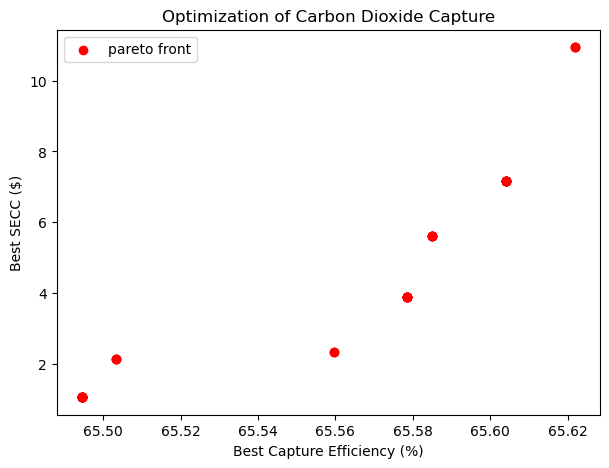

In [125]:
#PLot the optimization results
plt.figure(figsize=(7, 5))
plt.scatter(df_best_optimal["capture_efficiency_%"], df_best_optimal["SECC_$"], color="red", label="pareto front")
plt.title("Optimization of Carbon Dioxide Capture")
plt.xlabel("Best Capture Efficiency (%)")
plt.ylabel("Best SECC ($)")
plt.legend()

In [33]:
df_optimal.columns

Index(['caco3_flow_rate [kmol/hr]', 'calciner_temp [Deg C]',
       'pellet_moisture_frac', 'air_mol_flow_rate [kmol/hr]', 'RH_air',
       'DAC_column_height [m]', 'pellet_diameter [mm]',
       'DAC_ambient_temp [Deg C]', 'e_voidage'],
      dtype='object')

In [35]:
wrangled_df.columns

Index(['caco3_flow_rate_kmol/hr', 'calciner_temp_DegC', 'pellet_moisture_frac',
       'air_mol_flow_rate_kmol/hr', 'RH_air', 'DAC_column_height_m',
       'pellet_diameter_mm', 'DAC_ambient_temp_DegC', 'e_voidage',
       'capture_efficiency_%', 'SECC'],
      dtype='object')

In [ ]:
df_optimal.rename(columns=[{"caco3_flow_rate [kmol/hr]":caco3_flow_rate_kmol/hr}])